In [13]:
%pip install pandas
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install imbalanced-learn
%env SCIPY_ARRAY_API=1


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


In [14]:
# 📦 Imports
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils import load_and_preprocess_data
from src.model import build_weighted_model  # make sure this is imported
import csv
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE



In [15]:
# 1. Load and preprocess the dataset
X_train, X_test, y_train, y_test = load_and_preprocess_data("../data/dataset.csv")

In [21]:
from tensorflow.keras.models import load_model
model = load_model("../results/cnn_rnn_model.h5")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

📊 Ensemble Model Classification Report:

              precision    recall  f1-score   support

           0     0.9902    0.9866    0.9884      1939
           1     0.6176    0.6885    0.6512        61

    accuracy                         0.9775      2000
   macro avg     0.8039    0.8376    0.8198      2000
weighted avg     0.9788    0.9775    0.9781      2000



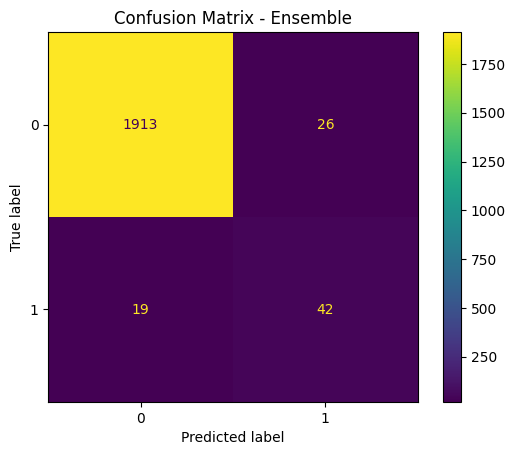

In [22]:
# ⚙️ Step 1: Flatten and train Random Forest
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
rf_probs = rf.predict_proba(X_test_rf)[:, 1]

# 🧠 Step 2: Predict with CNN-RNN (already trained)
cnn_probs = model.predict(X_test).flatten()

# 🤝 Step 3: Combine predictions
ensemble_probs = (cnn_probs + rf_probs) / 2
threshold = 0.36
ensemble_preds = (ensemble_probs > threshold).astype(int)

# 📊 Step 4: Evaluation
print("\n📊 Ensemble Model Classification Report:\n")
print(classification_report(y_test, ensemble_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, ensemble_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Ensemble")
plt.grid(False)
plt.show()